In [1]:
# Notebook used to make shadowgraphy movie

In [2]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation
import imageio
import os

import particle_tracker as pt
import ray_transfer_matrix as rtm
import yt.units

In [3]:
def make_electron_number_density(field, data):
    N_A = yt.units.yt_array.YTQuantity(6.02214076e23, "1/mol")
    proton_mass = yt.units.yt_array.YTQuantity(1.6726219e-24, 'g')
    electron_number_density = N_A*data["flash","dens"]*data["flash","ye"]/proton_mass
    return electron_number_density

In [4]:
ray_trace_dir = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_v0/raytrace_'
n_traces = 59
output_dir = '/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_shield_v0'

for i in range(n_traces): 
    ray_trace_dir = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_v0/raytrace_' + str(i).zfill(4)
    metadata = {}
    raytrace_metadata = ray_trace_dir + '/metadata.txt'
    
    with open(raytrace_metadata, 'r') as f:
        metadata_lines = f.readlines()
        for line in metadata_lines:
            key, value = line.strip().split(': ')
            metadata[key] = value
    print(metadata)
    
    ds = yt.load(metadata["flash_file"])
    ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell") # same here

    rf = np.load(f"{ray_trace_dir}/ray_output.npy")
    beam_size = float(metadata["beam_size"])
    photons = int(metadata["num_photons"])
    
    det_size = 2*float(metadata['beam_size'])*10**3 # 10^3 to convert into mm
    lens_rad=25
    length=400
    fp=0
    
    sh = rtm.Shadowgraphy(r0=rf, focal_plane=fp, L=length, R=lens_rad, Lx=det_size, Ly=det_size)
    sh.solve()

    # define LIONZ optical system
    focal_plane = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
    focal_plane = focal_plane.v # yt units are annoying as fuck
    print("focal plane:", focal_plane)
    
    offset_mm = 2 # offset for focusing
    Lens_FL = 400
    total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
    if Lens_FL == 400:
        d1= 450
    elif Lens_FL == 500:
        d1 = 584.3
    
    d2 =total_dist-d1
    Lens_Rad = .5*75/2 # radius of lens
    # Lx (int, optional): Detector size in x. Defaults to 18.
    # Ly (float, optional): Detector size in y. Defaults to 13.5.
    sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset_mm, L=Lens_FL, R=Lens_Rad) # must center grid
    # sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset_mm, L=Lens_FL, R=Lens_Rad) # must center grid
    sh.solve(d1=d1,d2=d2)
    sh.histogram(bin_scale = 7)
    # plot
    fig, axs = plt.subplots()
    cm='gray'
    #clim=[0,15]
    
    vmin=np.percentile(sh.H, 5)
    vmax=np.percentile(sh.H,90)
    
    clim=(0,vmax*3) # trial and error
    sh.plot(axs, cmap=cm, clim=clim)
    
    # add in time step
    time_ns = ds.current_time.in_units('ns').v
    axs.text(0.05, 0.95, f't = {time_ns:.2f} ns', 
             transform=axs.transAxes, 
             color='white', 
             fontsize=12, 
             fontweight='bold',
             verticalalignment='top',
             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none')) # Adds a readable background box
    
    #offset_mm = 0
    #sh_focused = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = 0, L=Lens_FL, R=Lens_Rad)
    #sh_focused.solve(d1=d1,d2=d2)
    #sh_focused.histogram(bin_scale = 7)
    
    plt.savefig(f'{output_dir}/sh_{str(i).zfill(4)}ns.png', bbox_inches='tight')

FileNotFoundError: [Errno 2] No such file or directory: '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_v0/raytrace_0000/metadata.txt'

# Animation

In [5]:
from matplotlib.animation import FFMpegWriter

ffmpeg_raw_path = "~/.conda/envs/myenv/bin/ffmpeg"
ffmpeg_full_path = os.path.expanduser(ffmpeg_raw_path)
plt.rcParams['animation.ffmpeg_path'] = ffmpeg_full_path
writer = FFMpegWriter(fps=20, codec='libx264')

/tmp/ipykernel_2455357/1304336931.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(os.path.join(flat_image_folder, f)) for f in flat_image_files]


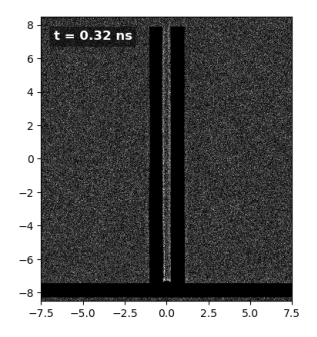

In [8]:
# Folder containing PNGs
flat_image_folder = "/home/timoney/scratch/timoney/MagShockZ/images/sh_3d_noshield_slc"
flat_image_files = sorted([f for f in os.listdir(flat_image_folder) if f.endswith(".png")])

# Read all images
images = [imageio.imread(os.path.join(flat_image_folder, f)) for f in flat_image_files]

fig, ax = plt.subplots()
img_display = ax.imshow(images[0])
ax.axis('off')  # optional: hide axes

height, width, _ = images[0].shape
fig.set_size_inches(width/100, height/100) # Assuming 100 DPI

def update(frame):
    img_display.set_data(images[frame])
    return [img_display]

ani = animation.FuncAnimation(fig, update, frames=len(images), interval=100)
# ani.save("animations/flat.gif", writer='pillow', fps=20)

writer = FFMpegWriter(fps=16, metadata=dict(artist='Me'), bitrate=1800)
ani.save("/home/timoney/scratch/timoney/MagShockZ/movies/sh_3d_noshield_slc.mp4", writer=writer)